# Multimodal GenAI: CLIP vs LLaVA
### A hands-on comparison of contrastive vs generative Vision-Language Models

**Vision-Language Models (VLMs)** connect visual and textual understanding in a shared
representation space. Two dominant paradigms:

- **CLIP (Contrastive Language-Image Pretraining)** — learns a joint embedding space
  where matching image-text pairs are close together. No generation, just similarity.

- **LLaVA (Large Language and Vision Assistant)** — a generative VLM that connects a
  vision encoder to an LLM, enabling captioning, VQA, and free-form reasoning about images.



## Working Of CLIP

CLIP has two encoders trained jointly:

- Image Encoder (ViT or ResNet) → image embedding vector
- Text Encoder (Transformer) → text embedding vector

Both are projected into the **same** embedding space. Training objective: maximize
cosine similarity for correct (image, text) pairs and minimize it for incorrect pairs,
across a batch (contrastive loss / InfoNCE).

At inference time, "classification" is really:
`argmax(cosine_similarity(image_embedding, text_embedding[i]))` over a set of candidate captions.

In [17]:
!pip install -q transformers torch torchvision pillow scikit-learn matplotlib accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.7 MB/s eta 0:00:00


In [4]:
import os
print(os.getcwd())

/content


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
os.chdir("/content/drive/My Drive/AI")

### Importing necessary libraries

In [7]:
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Load CLIP

In [8]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [9]:
def load_image(path_or_url):
    if path_or_url.startswith("http"):
        response = requests.get(path_or_url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(path_or_url).convert("RGB")
    return img

# Load a set of test images you'll reuse across experiments
image_paths = {
    "rasmalai": "rasmalai.jpg",       # your recurring demo image, if you have one
    "receipt": "receipt.jpg",
    "chart": "chart.jpg",
    "handwritten_math": "handwritten_math.jpg",
    "meme": "meme.jpg",
}

## Experiment 1: Zero-Shot Image Classification

rasmalai             99.88%
rice pudding         0.10%
gulab jamun          0.01%
a plate of curry     0.01%
a bowl of soup       0.00%


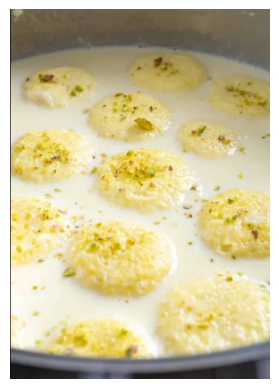

In [10]:
def clip_zero_shot(image, candidate_labels, top_k=5):
    inputs = clip_processor(
        text=[f"a photo of {label}" for label in candidate_labels],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

    ranked = sorted(zip(candidate_labels, probs), key=lambda x: -x[1])
    return ranked[:top_k]

img = load_image(image_paths["rasmalai"])
labels = ["rasmalai", "gulab jamun", "rice pudding", "a bowl of soup", "ice cream", "a plate of curry"]

results = clip_zero_shot(img, labels)
for label, prob in results:
    print(f"{label:20s} {prob*100:.2f}%")
plt.imshow(img); plt.axis("off"); plt.show()

handwritten math     91.37%
math                 7.06%
diagram              1.11%
chart                0.20%
handwritten text     0.20%


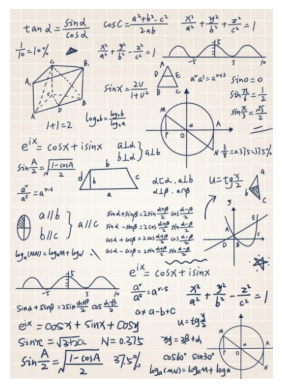

In [11]:
img = load_image(image_paths["handwritten_math"])
labels = [
    "math",
    "scribble",
    "handwritten math",
    "handwritten text",
    "printed text",
    "diagram",
    "chart",
    "table"
]

results = clip_zero_shot(img, labels)
for label, prob in results:
    print(f"{label:20s} {prob*100:.2f}%")
plt.imshow(img); plt.axis("off"); plt.show()

## Experiment 2: Image-Text Similarity

In [30]:
img = load_image(image_paths["rasmalai"])

In [31]:
def image_text_similarity(image, prompts):
    inputs = clip_processor(text=prompts, images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
        img_emb = outputs.image_embeds
        txt_emb = outputs.text_embeds
        img_emb = F.normalize(img_emb, dim=-1)
        txt_emb = F.normalize(txt_emb, dim=-1)
        sims = (img_emb @ txt_emb.T).cpu().numpy()[0]
    return dict(zip(prompts, sims))

prompts = [
    "a sweet Indian dessert",
    "a savory dish",
    "a dessert served in syrup",
    "a picture of a dog",
]
sims = image_text_similarity(img, prompts)
for p, s in sorted(sims.items(), key=lambda x: -x[1]):
    print(f"{s:.3f}  {p}")

0.281  a sweet Indian dessert
0.244  a savory dish
0.219  a dessert served in syrup
0.163  a picture of a dog


## Experiment 3: Embedding Visualization

In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def get_embedding(image):
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        output_obj = clip_model.get_image_features(pixel_values=inputs["pixel_values"])
        emb = output_obj.pooler_output # Extract the tensor from the output object
    return F.normalize(emb, dim=-1).cpu().numpy()[0]

embeddings = []
names = []
for name, path in image_paths.items():
    img = load_image(path)
    embeddings.append(get_embedding(img))
    names.append(name)

embeddings = np.array(embeddings)
print(embeddings.shape)

(5, 512)


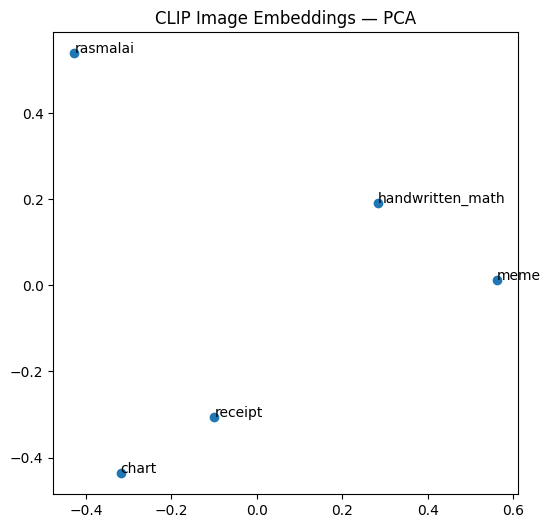

In [14]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(6,6))
plt.scatter(reduced[:,0], reduced[:,1])
for i, name in enumerate(names):
    plt.annotate(name, (reduced[i,0], reduced[i,1]))
plt.title("CLIP Image Embeddings — PCA")
plt.show()

*Note: t-SNE needs more points than PCA to be meaningful — with only 5 images it'll likely look arbitrary.*

## Experiment 4: Prompt Sensitivity

CLIP's zero-shot accuracy is known to vary significantly with prompt template wording
(the original CLIP paper uses an 80-template ensemble specifically to counteract this).
Here we measure that variance directly instead of assuming it.

In [23]:
def get_text_embedding(text):
    inputs = clip_processor(text=[text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        output_obj = clip_model.get_text_features(**inputs)
        emb = output_obj.pooler_output # Extract the tensor from the output object
    return F.normalize(emb, dim=-1).cpu().numpy()[0]

*prompt sensitivity test*

In [24]:
templates = [
    "{}",
    "a photo of {}",
    "a close-up photo of {}",
    "a picture of a {} on a plate",
    "an Indian dessert called {}",
    "a bowl containing {}",
]

def prompt_sensitivity_test(image, label, templates):
    img_emb = get_embedding(image)  # from Cell 9
    results = {}
    for t in templates:
        prompt = t.format(label)
        txt_emb = get_text_embedding(prompt)
        sim = float(np.dot(img_emb, txt_emb))  # both already normalized
        results[t] = sim
    return results

img = load_image(image_paths["rasmalai"])
label = "rasmalai"

sensitivity = prompt_sensitivity_test(img, label, templates)
for t, s in sorted(sensitivity.items(), key=lambda x: -x[1]):
    print(f"{s:.4f}  {t.format(label)}")

values = list(sensitivity.values())
print(f"\nMean: {np.mean(values):.4f}  Std: {np.std(values):.4f}  Range: {max(values)-min(values):.4f}")

0.3492  a picture of a rasmalai on a plate
0.3469  a close-up photo of rasmalai
0.3426  rasmalai
0.3421  an Indian dessert called rasmalai
0.3389  a photo of rasmalai
0.3334  a bowl containing rasmalai

Mean: 0.3422  Std: 0.0052  Range: 0.0158


In [28]:
import pandas as pd

                             rasmalai  gulab jamun  rice pudding
X                            0.342634     0.231450      0.262731
a photo of X                 0.338873     0.244976      0.270292
a close-up photo of X        0.346853     0.249167      0.277787
a picture of a X on a plate  0.349233     0.219464      0.249332
an Indian dessert called X   0.342073     0.242438      0.290083
a bowl containing X          0.333410     0.234467      0.244810


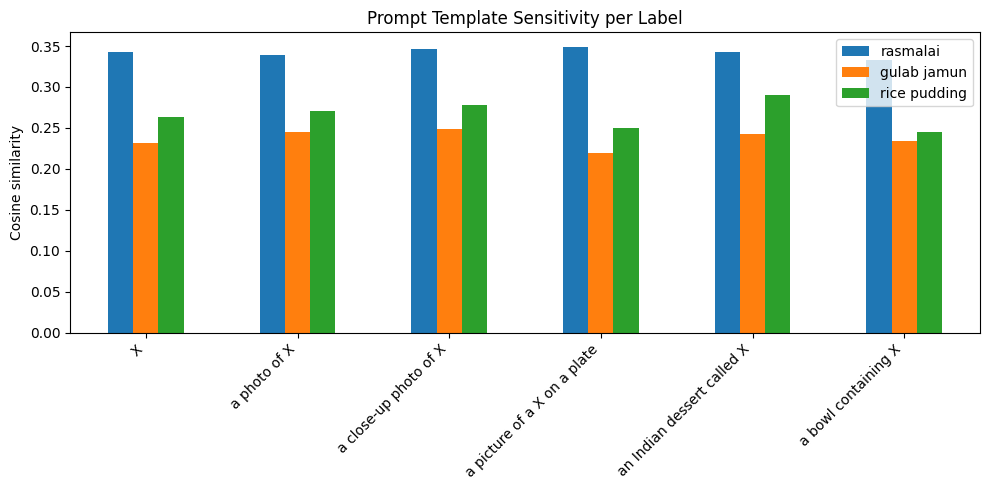

In [29]:
labels_to_test = ["rasmalai", "gulab jamun", "rice pudding"]

all_results = {}
for lbl in labels_to_test:
    all_results[lbl] = prompt_sensitivity_test(img, lbl, templates)

df_sensitivity = pd.DataFrame(all_results)
df_sensitivity.index = [t.format("X") for t in templates]
print(df_sensitivity)

df_sensitivity.plot(kind="bar", figsize=(10,5))
plt.ylabel("Cosine similarity")
plt.title("Prompt Template Sensitivity per Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()